If GLUE package not published, use the uploaded result table to generate plots:
../results/GLUE/glomerular_gcmc_withshuffle_24bg_high_low_scale_0.0_10000points.csv

In [ ]:
import numpy as np
# from coding_model import *
from FigS6_coding_model_fanofactor import *
from gcmc import gcmc_analysis
from gcmc.simulation_analysis import simulation_capacity
from gcmc.preprocess import downsample_manifolds, reallocate_origin, shuffle_manifolds
import time
from matplotlib.lines import Line2D
import matplotlib.cm as cm
import matplotlib.colors as mcolors
from joblib import Parallel, delayed
import numpy as np
import time
import pandas as pd

# generate responses and compute geometry

In [ ]:
# main run + shuffled run (~1.5 hours on macbook M4 pro) - 
from joblib import Parallel, delayed
import numpy as np
import time
import pandas as pd

sigmas = [0, 1e-2, 1e-1, 2e-1, 4e-1]
cue_concs = [1.0, 1e-3]
bg_concs = [1.0, 1e-3]
train_cue_concs = np.arange(10)
total_bg = 24
scale = 0.0
n_points = 10000

def process_combo(sigma, bg_conc, train_cue_conc):
    """Generate data for this triple, loop over conc_idx & n_bg, run gcmc_analysis."""
    results_local = []
    # 1) generate all the train/test sets for this combination
    X_train, y_train, X_tests, y_tests, all_test_concs, all_target_concs = \
        generate_datasets(
            n_train=1,
            n_test=n_points,
            cue_concs=cue_concs,
            train_cue_conc=train_cue_conc,
            sigma=sigma,
            cue=-1,
            n_bg=-1,
            model_params=init_model_parameters(rho=0.5, bg_conc=bg_conc, total_bg=total_bg, seed=int(train_cue_conc)),
            return_params=False
        )
    # 2) for each test‐concentration index and each number of backgrounds
    for conc_idx in range(len(cue_concs)):
        for n_bg in [0, 1, 2, 4, 8, 12, 16]:
            mask = np.sum(all_test_concs[conc_idx,:,2:] > 0, axis=-1) == n_bg
            X_test = X_tests[conc_idx][mask]
            y_test = y_tests[conc_idx][mask]
            mfld1 = X_test[y_test == 0].T
            mfld2 = X_test[y_test == 1].T
            manifolds = [mfld1, mfld2]
            dichotomies = [[-1, 1]]

            start = time.time()
            # manifolds = downsample_manifolds(manifolds, n_points=n_points)
            realloc_manifolds = reallocate_origin(manifolds, scale=scale) # RESCALE ORIGIN (add bias)

            try:
                ret = gcmc_analysis(realloc_manifolds, dichotomies)
                simcap = simulation_capacity(realloc_manifolds, dichotomies)
                elapsed = time.time() - start

                # shuffled capacity
                manifolds_shuffled = shuffle_manifolds(manifolds, seed=42)
                manifolds_reallocated = reallocate_origin(manifolds_shuffled, scale=scale)
                shuffle_ret = gcmc_analysis(manifolds_reallocated, dichotomies)


                # optional: print shapes & timing
                print(f"[σ={sigma}, bg={bg_conc}, train_cue={train_cue_conc}, "
                    f"conc={cue_concs[conc_idx]:.1e}, n_bg={n_bg}] "
                    f"→ cap={ret['capacity']:.2f}, sim_cap={simcap:.2f} in {elapsed:.1f}s")

                results_local.append([
                    sigma,
                    train_cue_conc,
                    bg_conc,
                    cue_concs[conc_idx],
                    n_bg,
                    ret['capacity'],
                    simcap,
                    ret['dimension'],
                    ret['radius'],
                    ret['utility'],
                    ret['center_alignment'],
                    ret['axis_alignment'],
                    ret['center_axis_alignment'],
                    shuffle_ret['capacity'],
                    shuffle_ret['dimension'],
                    shuffle_ret['radius'],
                    shuffle_ret['utility'],
                    shuffle_ret['center_alignment'],
                    shuffle_ret['axis_alignment'],
                    shuffle_ret['center_axis_alignment'],
                ])
            except:
                results_local.append([sigma,
                train_cue_conc,
                bg_conc,
                cue_concs[conc_idx],
                n_bg,
                None,
                None,
                None])
            
    return results_local

# build list of all combinations
combos = [
    (sigma, bg_conc, train_cue_conc)
    for sigma in sigmas
    for bg_conc in bg_concs
    for train_cue_conc in train_cue_concs
]

# run in parallel
all_results = Parallel(
    n_jobs=12,         # use all available cores
    verbose=10,        # a little progress info
    backend='loky'     # default safe backend
)(
    delayed(process_combo)(sigma, bg_conc, train_cue_conc)
    for sigma, bg_conc, train_cue_conc in combos
)

# flatten list-of-lists
results = [row for sublist in all_results for row in sublist]

# assume `results` is a list of lists in the form:
# [sigma, train_cue_conc, bg_conc, cue_conc, n_bg, capacity, dimension, radius]
columns = [
    'sigma',
    'train_cue_conc',
    'bg_conc',
    'cue_conc',
    'n_bg',
    'capacity',
    'capacity_simulation',
    'dimension',
    'radius',
    'utility',
    'center_alignment',
    'axis_alignment',
    'center_axis_alignment',
    'shuffle_capacity',
    'shuffle_dimension',
    'shuffle_radius',
    'shuffle_utility',
    'shuffle_center_alignment',
    'shuffle_axis_alignment',
    'shuffle_center_axis_alignment'
]

# Create DataFrame
df = pd.DataFrame(results, columns=columns)

# (optional) inspect
print(df.head())

# Save to CSV (no index column)
df.to_csv(f'../results/GLUE/glomerular_gcmc_withshuffle_{total_bg}bg_high_low_scale_{scale}_{n_points}points.csv', index=False)

[Parallel(n_jobs=12)]: Using backend LokyBackend with 12 concurrent workers.
/Users/georgecai/miniforge3/envs/gcmc/lib/python3.10/site-packages/gcmc/gcmc_analysis.py:633: RuntimeWarning: invalid value encountered in sqrt
  radius_cone = np.sqrt(radius_numerator_cone / radius_denominator_cone)


[σ=0, bg=1.0, train_cue=4, conc=1.0e+00, n_bg=4] → cap=0.07, sim_cap=0.07 in 25.0s
[σ=0, bg=1.0, train_cue=3, conc=1.0e+00, n_bg=4] → cap=0.08, sim_cap=0.08 in 22.8s
[σ=0, bg=0.001, train_cue=1, conc=1.0e+00, n_bg=8] → cap=0.21, sim_cap=0.22 in 18.6s
[σ=0, bg=1.0, train_cue=7, conc=1.0e+00, n_bg=8] → cap=0.07, sim_cap=0.06 in 18.4s
[σ=0, bg=0.001, train_cue=0, conc=1.0e+00, n_bg=8] → cap=0.23, sim_cap=0.22 in 20.5s
[σ=0, bg=1.0, train_cue=8, conc=1.0e+00, n_bg=8] → cap=0.08, sim_cap=0.08 in 24.9s
[σ=0, bg=1.0, train_cue=1, conc=1.0e+00, n_bg=8] → cap=0.05, sim_cap=0.05 in 25.7s
[σ=0, bg=1.0, train_cue=6, conc=1.0e+00, n_bg=8] → cap=0.05, sim_cap=0.05 in 22.1s
[σ=0, bg=1.0, train_cue=2, conc=1.0e+00, n_bg=8] → cap=0.05, sim_cap=0.05 in 27.5s
[σ=0, bg=1.0, train_cue=5, conc=1.0e+00, n_bg=8] → cap=0.06, sim_cap=0.06 in 23.8s
[σ=0, bg=1.0, train_cue=9, conc=1.0e+00, n_bg=8] → cap=0.06, sim_cap=0.06 in 29.2s
[σ=0, bg=1.0, train_cue=3, conc=1.0e+00, n_bg=8] → cap=0.06, sim_cap=0.06 in 23.2s


[Parallel(n_jobs=12)]: Done   1 tasks      | elapsed:  6.8min


[σ=0, bg=1.0, train_cue=7, conc=1.0e-03, n_bg=8] → cap=0.02, sim_cap=0.02 in 47.0s
[σ=0, bg=1.0, train_cue=8, conc=1.0e-03, n_bg=8] → cap=0.03, sim_cap=0.03 in 36.4s


/Users/georgecai/miniforge3/envs/gcmc/lib/python3.10/site-packages/gcmc/gcmc_analysis.py:633: RuntimeWarning: invalid value encountered in sqrt
  radius_cone = np.sqrt(radius_numerator_cone / radius_denominator_cone)


...

[Parallel(n_jobs=12)]: Done  74 tasks      | elapsed: 71.3min


[σ=0.4, bg=1.0, train_cue=1, conc=1.0e+00, n_bg=16] → cap=0.02, sim_cap=0.02 in 55.1s
[σ=0.2, bg=0.001, train_cue=6, conc=1.0e-03, n_bg=12] → cap=0.04, sim_cap=0.04 in 27.7s
[σ=0.4, bg=1.0, train_cue=0, conc=1.0e-03, n_bg=0] → cap=0.07, sim_cap=0.07 in 24.7s
[σ=0.2, bg=0.001, train_cue=8, conc=1.0e-03, n_bg=8] → cap=0.07, sim_cap=0.08 in 27.7s
[σ=0.2, bg=0.001, train_cue=4, conc=1.0e-03, n_bg=16] → cap=0.04, sim_cap=0.04 in 28.2s
[σ=0.4, bg=1.0, train_cue=4, conc=1.0e+00, n_bg=4] → cap=0.03, sim_cap=0.03 in 27.8s
[σ=0.2, bg=0.001, train_cue=7, conc=1.0e-03, n_bg=8] → cap=0.07, sim_cap=0.07 in 25.4s
[σ=0.2, bg=0.001, train_cue=9, conc=1.0e-03, n_bg=4] → cap=0.07, sim_cap=0.07 in 22.7s
[σ=0.4, bg=1.0, train_cue=3, conc=1.0e+00, n_bg=12] → cap=0.02, sim_cap=0.02 in 41.3s
[σ=0.2, bg=0.001, train_cue=5, conc=1.0e-03, n_bg=16] → cap=0.05, sim_cap=0.05 in 27.6s
[σ=0.4, bg=1.0, train_cue=5, conc=1.0e+00, n_bg=0] → cap=0.19, sim_cap=0.20 in 21.0s
[σ=0.4, bg=1.0, train_cue=1, conc=1.0e-03, n_bg=

[Parallel(n_jobs=12)]: Done  88 out of 100 | elapsed: 85.9min remaining: 11.7min


[σ=0.4, bg=0.001, train_cue=7, conc=1.0e+00, n_bg=2] → cap=0.13, sim_cap=0.12 in 22.9s
[σ=0.4, bg=1.0, train_cue=6, conc=1.0e-03, n_bg=12] → cap=0.01, sim_cap=0.01 in 113.6s
[σ=0.4, bg=0.001, train_cue=4, conc=1.0e+00, n_bg=16] → cap=0.09, sim_cap=0.08 in 24.5s
[σ=0.4, bg=0.001, train_cue=3, conc=1.0e-03, n_bg=0] → cap=0.07, sim_cap=0.07 in 22.7s
[σ=0.4, bg=0.001, train_cue=2, conc=1.0e-03, n_bg=1] → cap=0.06, sim_cap=0.06 in 29.4s
[σ=0.4, bg=0.001, train_cue=5, conc=1.0e+00, n_bg=16] → cap=0.07, sim_cap=0.07 in 27.4s
[σ=0.4, bg=0.001, train_cue=6, conc=1.0e+00, n_bg=8] → cap=0.09, sim_cap=0.09 in 27.1s
[σ=0.4, bg=1.0, train_cue=9, conc=1.0e-03, n_bg=12] → cap=0.01, sim_cap=0.01 in 97.9s
[σ=0.4, bg=0.001, train_cue=9, conc=1.0e+00, n_bg=0] → cap=0.18, sim_cap=0.18 in 20.9s
[σ=0.4, bg=0.001, train_cue=8, conc=1.0e+00, n_bg=4] → cap=0.12, sim_cap=0.12 in 26.8s
[σ=0.4, bg=0.001, train_cue=7, conc=1.0e+00, n_bg=4] → cap=0.11, sim_cap=0.12 in 25.4s
[σ=0.4, bg=1.0, train_cue=5, conc=1.0e-03,

[Parallel(n_jobs=12)]: Done 100 out of 100 | elapsed: 94.0min finished


# Fig4: geometric trends (use uploaded result)

In [14]:
# import scienceplots
plt.style.use('default') #['science', 'no-latex'])
total_bg = 24
scale = 0.0
n_points = 10000
df = pd.read_csv(f'../results/GLUE/glomerular_gcmc_withshuffle_{total_bg}bg_high_low_scale_{scale}_{n_points}points.csv')
sigmas = [0, 1e-2, 1e-1, 2e-1, 4e-1]
df = df[df['sigma'] > 0]
df['Background'] = df['bg_conc']
df['Background odors'] = df['n_bg']
df['Cue'] = df['cue_conc']
# df = df[df.cue_conc == df.train_cue_conc] # subset to when the train and test cue concentrations are equal

# 1) define exactly how each n_bg level should look
palette = {
    0:  'black',    # n_bg==0
    16:  '#deebf7',  # lightest blue
    12:  '#c6dbef',
    8:  '#9ecae1',
    4:  '#6baed6',
    2: '#3182bd',
    1: '#08519c',  # darkest blue
}
palette = {
    0:  'black',    # n_bg==0
    1:  '#deebf7',  # lightest blue
    2:  '#c6dbef',
    4:  '#9ecae1',
    8:  '#6baed6',
    12: '#3182bd',
    16: '#08519c',  # darkest blue
}

palette = {
    0:  'black',
    1:  '#ebb08c',
    2:  "#dc7756",
    4:  '#b9324e',
    8:  '#9b2857',
    12:  '#682946',
    16:  '#3e0f2b',
}


dashes = {
    0:  (3, 1),  # dashed for n_bg==0
    1:  '',      # solid for all others
    2:  '',
    4:  '',
    8:  '',
    12: '',
    16: '',
}

In [15]:
df['capacity_ratio_shuffle'] = df.capacity / df.shuffle_capacity
sub_df = df[np.logical_or(df['cue_conc'] == 1.0, df['cue_conc'] == 1e-3)]
sub_df = sub_df[np.logical_or(sub_df['Background'] == 1.0, sub_df['Background'] == 1e-3)]

sub_df[(sub_df['cue_conc'] == 1.0) & (sub_df['Background'] == 1.0) & (df.sigma == 0.0)]

,sigma,train_cue_conc,bg_conc,cue_conc,n_bg,capacity,capacity_simulation,dimension,radius,utility,...,shuffle_dimension,shuffle_radius,shuffle_utility,shuffle_center_alignment,shuffle_axis_alignment,shuffle_center_axis_alignment,Background,Background odors,Cue,capacity_ratio_shuffle


/var/folders/jx/yp9jv79d1gd51pyk2rg3h81m0000gq/T/ipykernel_70222/2632707731.py:41: UserWarning: Attempt to set non-positive ylim on a log-scaled axis will be ignored.
  plt.ylim(0, 4.0)


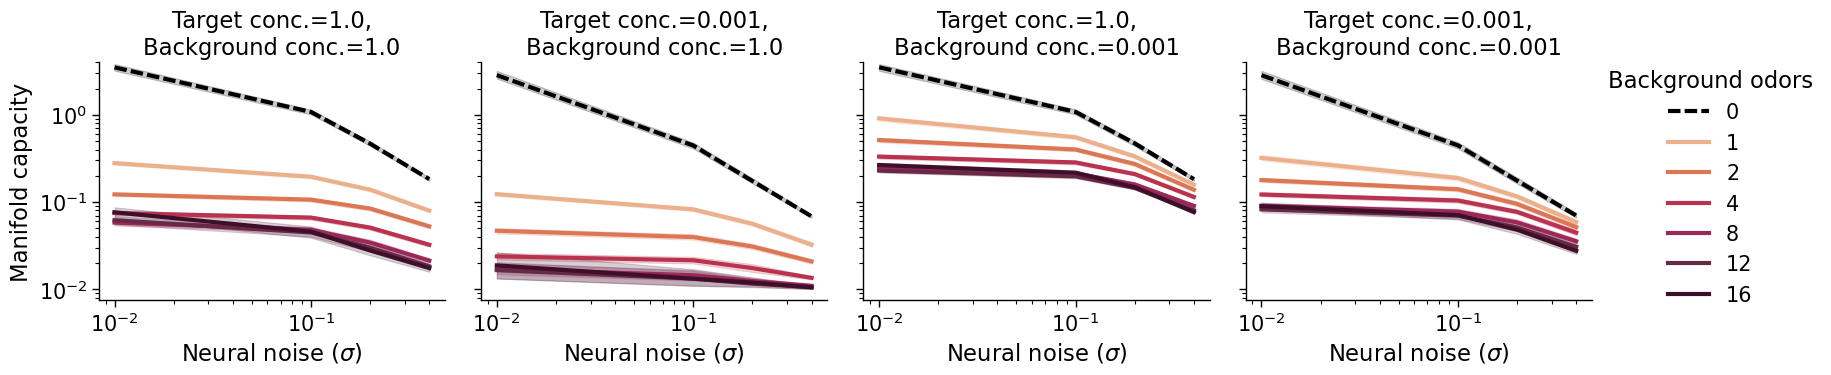

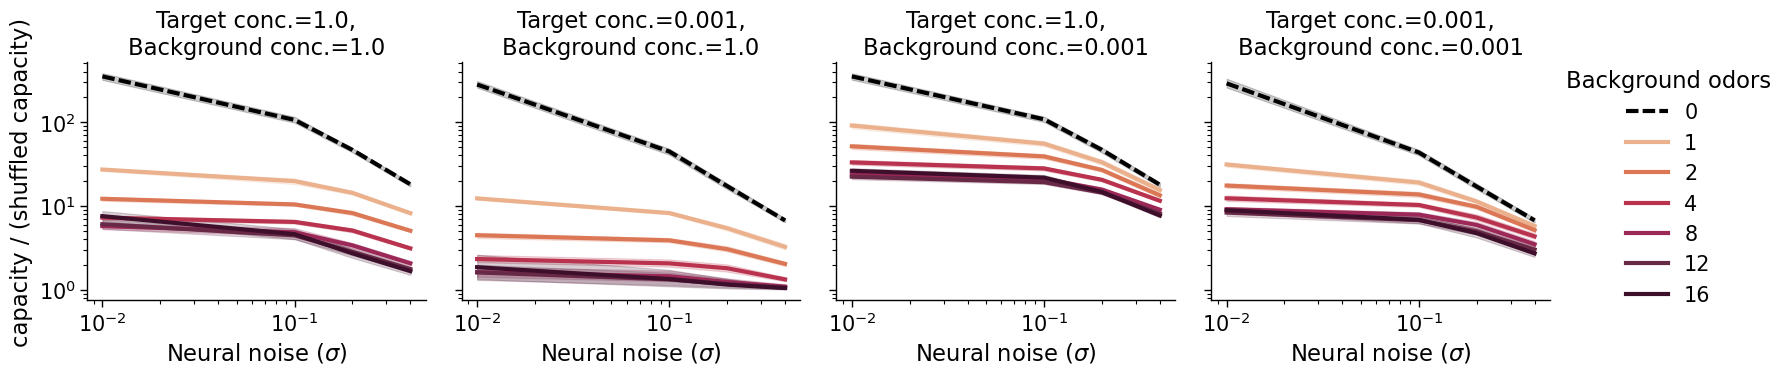

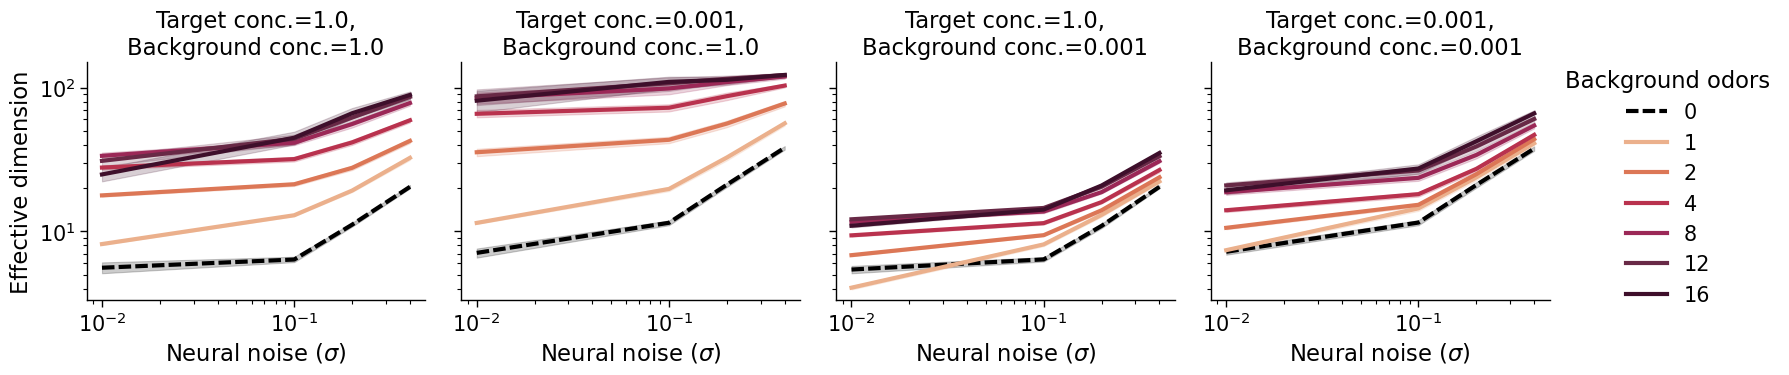

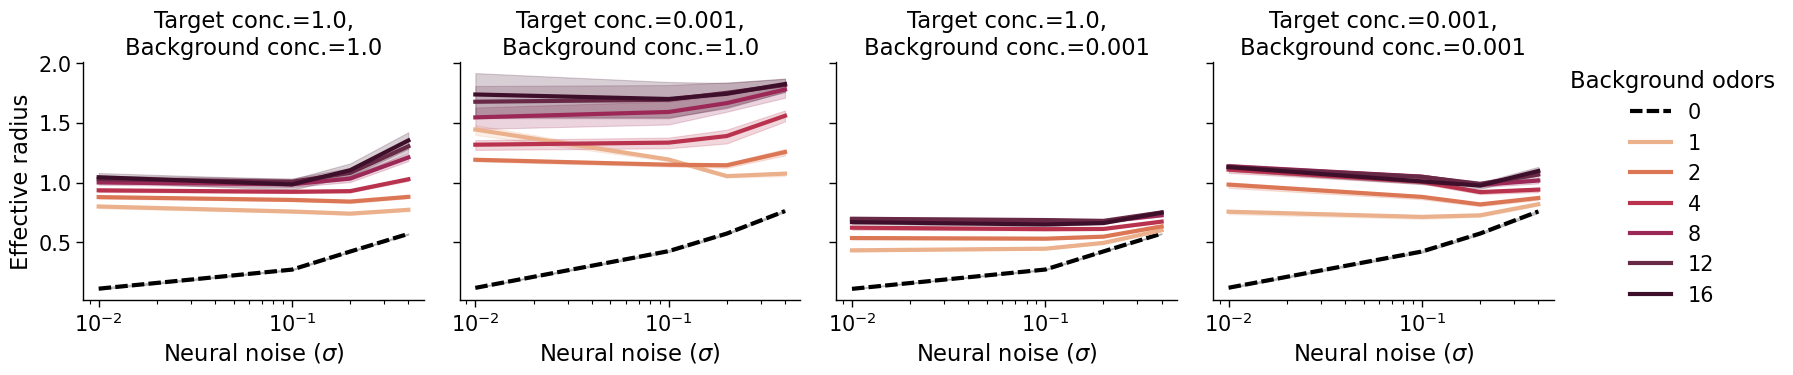

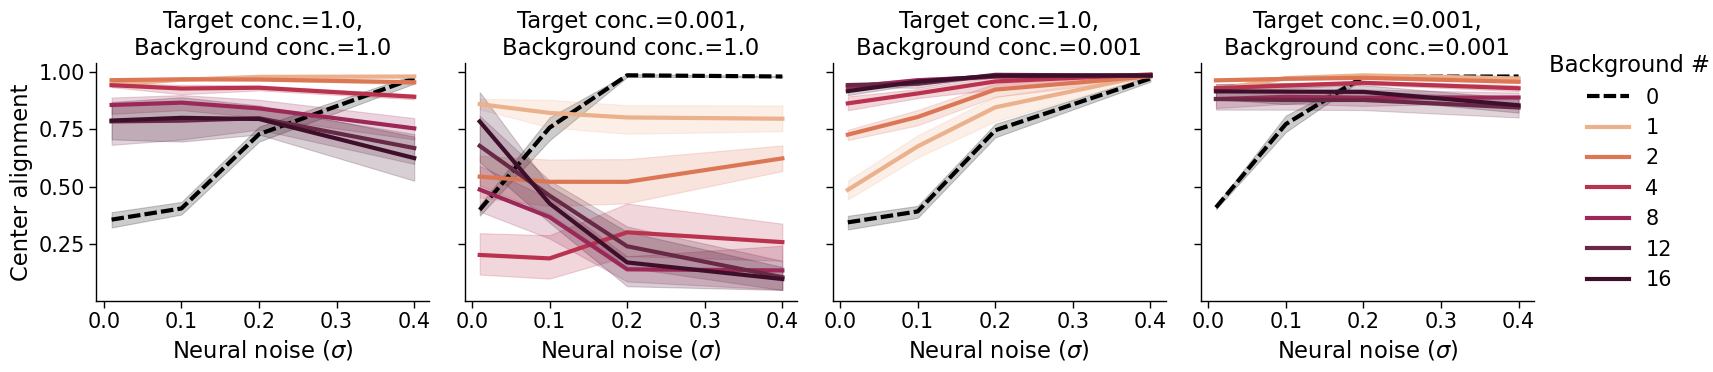

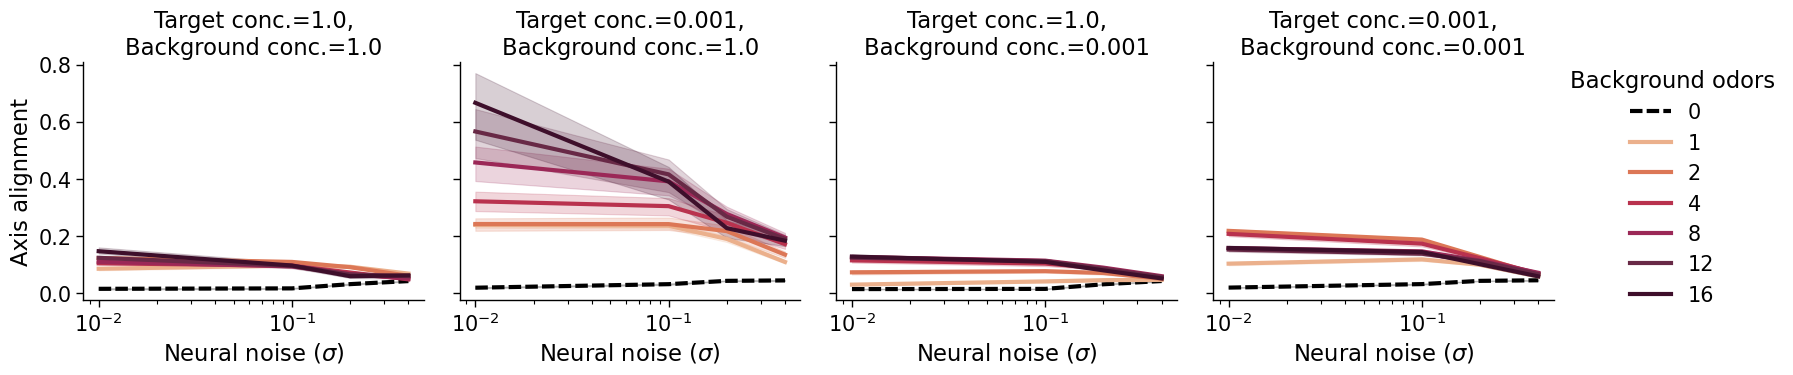

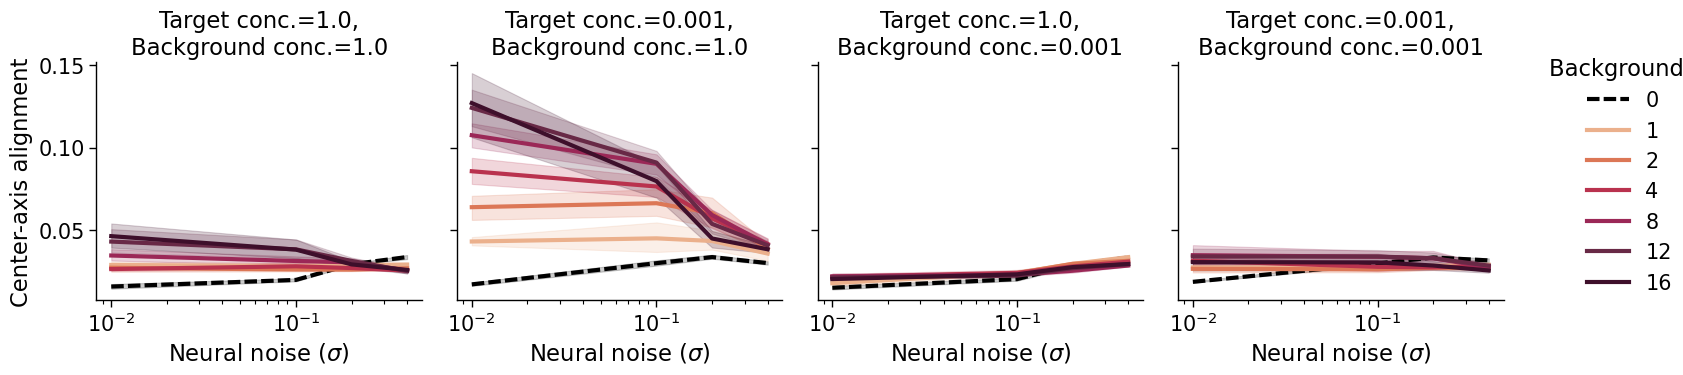

In [ ]:
# pick out just the two cue_conc and two Background values
df['capacity_ratio_shuffle'] = df.capacity / df.shuffle_capacity
sub_df = df[np.logical_or(df['cue_conc'] == 1.0, df['cue_conc'] == 1e-3)]
sub_df = sub_df[np.logical_or(sub_df['Background'] == 1.0, sub_df['Background'] == 1e-3)]



# create a combined facet column, e.g. "Cue=1.0, BG=1e-4"
sub_df = sub_df.copy()
sub_df['panel_label'] = (
    'Target conc.=' + sub_df['cue_conc'].astype(str)
    + ',\nBackground conc.=' + sub_df['Background'].astype(str)
)

## scale all fonts
sns.set_context("paper", font_scale=1.7)  # "talk", "notebook", "paper", "poster"

# now facet on that single variable (4 unique values → 1 row of 4)
g = sns.relplot(
    data=sub_df,
    x='sigma', y='capacity',
    hue='Background odors',
    col='panel_label',           # only one faceting dimension
    kind='line',
    linewidth=3.,             # <<-- Thicker lines
    dashes=dashes,
    style='Background odors',
    palette=palette,
    facet_kws={'sharex': True, 'sharey': True},
    height=4, aspect=1.0
)
for ax, title in zip(g.axes.flat, g.col_names):
    ax.set_title(title)  # Set just the value, not "panel_label = value"
# apply your scales/limits/labels
plt.xscale('log')
plt.yscale('log')
plt.ylim(0, 4.0)
g.set_axis_labels('Neural noise ($\sigma$)', 'Manifold capacity')

# plt.tight_layout()
plt.savefig(f'../figures/capacity_bg_neural_noise_1x4_scale_{scale}_{n_points}points.svg', dpi=600)
plt.savefig(f'../figures/capacity_bg_neural_noise_1x4_scale_{scale}_{n_points}points.png', dpi=600)


# now facet on that single variable (4 unique values → 1 row of 4)
g = sns.relplot(
    data=sub_df,
    x='sigma', y='capacity_ratio_shuffle',
    hue='Background odors',
    col='panel_label',           # only one faceting dimension
    kind='line',
    linewidth=3.,             # <<-- Thicker lines
    dashes=dashes,
    style='Background odors',
    palette=palette,
    facet_kws={'sharex': True, 'sharey': True},
    height=4, aspect=1.0
)
for ax, title in zip(g.axes.flat, g.col_names):
    ax.set_title(title)  # Set just the value, not "panel_label = value"
# apply your scales/limits/labels
plt.xscale('log')
plt.yscale('log')
# plt.ylim(1.0, 100.0)
g.set_axis_labels('Neural noise ($\sigma$)', 'capacity / (shuffled capacity)')

# plt.tight_layout()
plt.savefig(f'../figures/capacity_shuffle_ratio_bg_neural_noise_1x4_scale_{scale}_{n_points}points.svg', dpi=600)
plt.savefig(f'../figures/capacity_shuffle_ratio_bg_neural_noise_1x4_scale_{scale}_{n_points}points.png', dpi=600)



# now facet on that single variable (4 unique values → 1 row of 4)
g = sns.relplot(
    data=sub_df,
    x='sigma', y='dimension',
    hue='Background odors',
    col='panel_label',           # only one faceting dimension
    kind='line',
    linewidth=3.,             # <<-- Thicker lines
    dashes=dashes,
    style='Background odors',
    palette=palette,
    facet_kws={'sharex': True, 'sharey': True},
    height=4, aspect=1.0
)
for ax, title in zip(g.axes.flat, g.col_names):
    ax.set_title(title)  # Set just the value, not "panel_label = value"

# apply your scales/limits/labels
plt.xscale('log')
plt.yscale('log')

# plt.ylim(0, 1.5)
g.set_axis_labels('Neural noise ($\sigma$)', 'Effective dimension')

# plt.tight_layout()
plt.savefig(f'../figures/dimension_bg_neural_noise_1x4_scale_{scale}_{n_points}points.svg', dpi=600)
plt.savefig(f'../figures/dimension_bg_neural_noise_1x4_scale_{scale}_{n_points}points.png', dpi=600)


# now facet on that single variable (4 unique values → 1 row of 4)
g = sns.relplot(
    data=sub_df,
    x='sigma', y='radius',
    hue='Background odors',
    col='panel_label',           # only one faceting dimension
    kind='line',
        linewidth=3.,             # <<-- Thicker lines
dashes=dashes,
    style='Background odors',
    palette=palette,
    facet_kws={'sharex': True, 'sharey': True},
    height=4, aspect=1.0
)
for ax, title in zip(g.axes.flat, g.col_names):
    ax.set_title(title)  # Set just the value, not "panel_label = value"

# apply your scales/limits/labels
plt.xscale('log')
# plt.yscale('log')
# plt.ylim(0, 1.5)
g.set_axis_labels('Neural noise ($\sigma$)', 'Effective radius')

# plt.tight_layout()
plt.savefig(f'../figures/radius_bg_neural_noise_1x4_scale_{scale}_{n_points}points.svg', dpi=600)
plt.savefig(f'../figures/radius_bg_neural_noise_1x4_scale_{scale}_{n_points}points.png', dpi=600)

# now facet on that single variable (4 unique values → 1 row of 4)
g = sns.relplot(
    data=sub_df,
    x='sigma', y='center_alignment',
    hue='Background odors',
    col='panel_label',           # only one faceting dimension
    kind='line',
        linewidth=3.,             # <<-- Thicker lines
dashes=dashes,
    style='Background odors',
    palette=palette,
    facet_kws={'sharex': True, 'sharey': True},
    height=4, aspect=1.0
)
for ax, title in zip(g.axes.flat, g.col_names):
    ax.set_title(title)  # Set just the value, not "panel_label = value"

# apply your scales/limits/labels
# plt.xscale('log')
# plt.ylim(0, 1.5)
g.set_axis_labels('Neural noise ($\sigma$)', 'Center alignment')
g._legend.set_title("Background #")
g.fig.subplots_adjust(right=0.85)
g._legend.set_bbox_to_anchor((0.84, 0.5))  # (x, y) relative to the axes bbox
g._legend.set_loc("center left")

# plt.tight_layout()
plt.savefig(f'../figures/center_alignment_bg_neural_noise_1x4_scale_{scale}_{n_points}points.svg', dpi=600)
plt.savefig(f'../figures/center_alignment_bg_neural_noise_1x4_scale_{scale}_{n_points}points.png', dpi=600)


# now facet on that single variable (4 unique values → 1 row of 4)
g = sns.relplot(
    data=sub_df,
    x='sigma', y='axis_alignment',
    hue='Background odors',
    col='panel_label',           # only one faceting dimension
    kind='line',
        linewidth=3.,             # <<-- Thicker lines
dashes=dashes,
    style='Background odors',
    palette=palette,
    facet_kws={'sharex': True, 'sharey': True},
    height=4, aspect=1.0
)
for ax, title in zip(g.axes.flat, g.col_names):
    ax.set_title(title)  # Set just the value, not "panel_label = value"

# apply your scales/limits/labels
plt.xscale('log')
# plt.ylim(0, 1.5)
g.set_axis_labels('Neural noise ($\sigma$)', 'Axis alignment')
plt.savefig(f'../figures/axis_alignment_bg_neural_noise_1x4_scale_{scale}_{n_points}points.svg', dpi=600)
plt.savefig(f'../figures/axis_alignment_bg_neural_noise_1x4_scale_{scale}_{n_points}points.png', dpi=600)


# now facet on that single variable (4 unique values → 1 row of 4)
g = sns.relplot(
    data=sub_df,
    x='sigma', y='center_axis_alignment',
    hue='Background odors',
    col='panel_label',           # only one faceting dimension
    kind='line',
        linewidth=3.,             # <<-- Thicker lines
dashes=dashes,
    style='Background odors',
    palette=palette,
    facet_kws={'sharex': True, 'sharey': True},
    height=4, aspect=1.0
)
for ax, title in zip(g.axes.flat, g.col_names):
    ax.set_title(title)  # Set just the value, not "panel_label = value"

# apply your scales/limits/labels
plt.xscale('log')
# plt.ylim(0, 1.5)
g.set_axis_labels('Neural noise ($\sigma$)', 'Center-axis alignment')
g._legend.set_title("Background #")
g.fig.subplots_adjust(right=0.85)
g._legend.set_bbox_to_anchor((0.84, 0.5))  # (x, y) relative to the axes bbox
g._legend.set_loc("center left")

plt.savefig(f'../figures/center_axis_alignment_bg_neural_noise_1x4_scale_{scale}_{n_points}points.svg', dpi=600)
plt.savefig(f'../figures/center_axis_alignment_bg_neural_noise_1x4_scale_{scale}_{n_points}points.png', dpi=600)


# SDT Gaussianity assumption check

In [21]:
sigmas = [0, 1e-2, 1e-1, 2e-1, 4e-1] 
cue_concs = np.logspace(-6, 2, 9)[::2]
bg_concs = np.logspace(-6, 2, 9)[::2]
train_cue_concs = np.logspace(-6, 2, 9)[::3]

for sigma in sigmas[-2:-1]: #[-2:-1]: #[-3:-2]:
    for bg_conc in bg_concs[-3:-2]:
        for train_cue_conc in train_cue_concs[-2:-1]:
            X_train, y_train, X_tests, y_tests, all_test_concs, all_target_concs = generate_datasets(n_train=1, n_test=6400, cue_concs=cue_concs, train_cue_conc=train_cue_conc,
                sigma=sigma, cue=-1, n_bg=-1, model_params=init_model_parameters(rho=0.5, bg_conc=bg_conc), return_params=False)


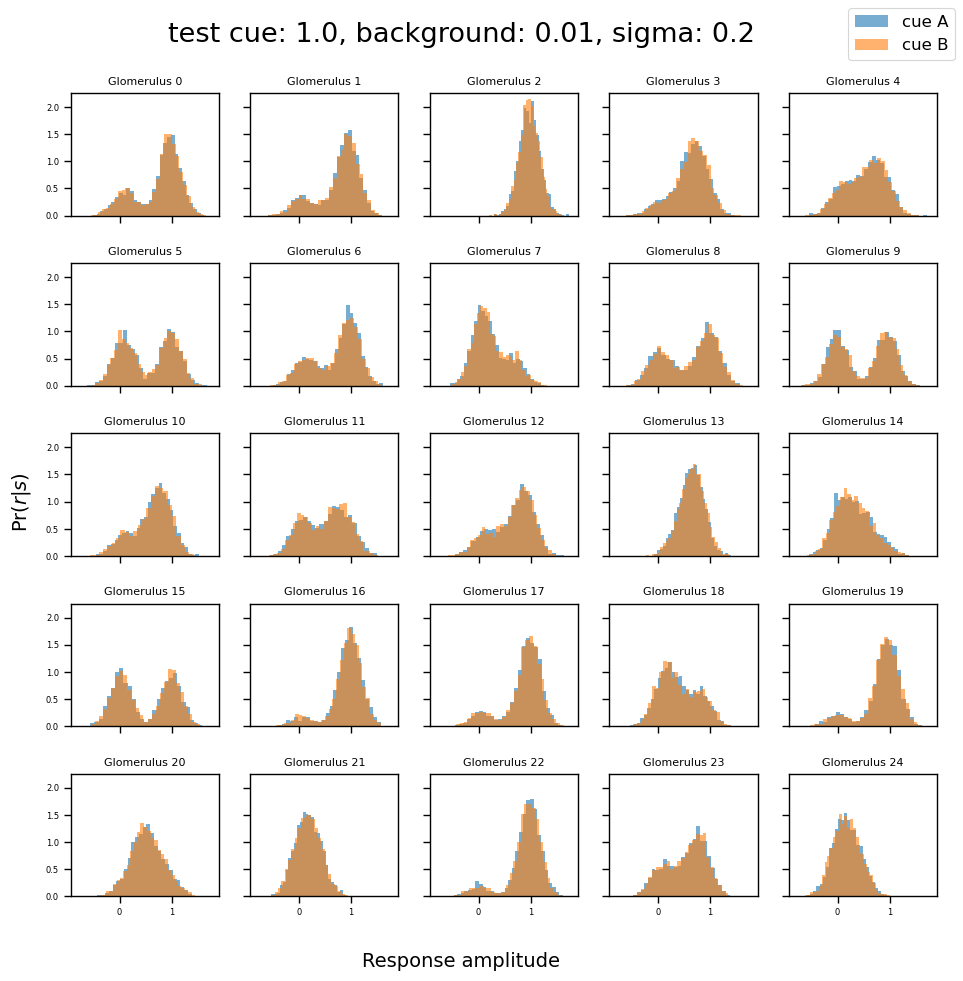

In [22]:
# how many glomeruli to plot
n_gloms = 25
test_conc_idx = 3
test_conc = cue_concs[test_conc_idx]

# grid layout: 10 columns, compute rows automatically
ncols = 5
nrows = int(np.ceil(n_gloms / ncols))

# masks for cue A vs. cue B
A_mask = (y_tests[0] == 1)
B_mask = ~A_mask

# create the subplots
fig, axes = plt.subplots(nrows, ncols, figsize=(10, 10), sharex=True, sharey=True)
axes = axes.flatten()

for idx in range(n_gloms):
    ax = axes[idx]
    ax.hist(X_tests[test_conc_idx, :, idx][A_mask], label='cue A', density=True, alpha=0.6, bins=30)
    ax.hist(X_tests[test_conc_idx, :, idx][B_mask], label='cue B', density=True, alpha=0.6, bins=30)
    ax.set_title(f'Glomerulus {idx}', fontsize=8)
    ax.tick_params(labelsize=6)

# remove any extra axes if n_gloms < nrows*ncols
for ax in axes[n_gloms:]:
    fig.delaxes(ax)
    
# one shared legend
fig.legend(['cue A', 'cue B'], loc='upper right', fontsize=12)

# overall labels
fig.text(0.5, 0.04, 'Response amplitude', ha='center', va='center', fontsize=14)
fig.text(0.06, 0.5, '$\Pr(r|s)$', ha='center', va='center', rotation='vertical', fontsize=14)
fig.suptitle(f'test cue: {test_conc}, background: {bg_conc}, sigma: {sigma}')

plt.tight_layout(rect=[0.06, 0.06, 1, 1])  # leave space for the shared labels
plt.show()
